# Build an accuracy model
### plan is to determine accuracy by using a large sample of span execution lengths and mean energy for those spans. Accuracy is then whether an indiividual span energy value is within X% of the mean span energy. Will then use data around span execution length (cpu_ms), active_interval_ms (active scraping interval), and potentially other variables to build a model.
- may add binary columns around within % of mean as potential model target
- try multi-linear regression since it would be nice to have a simple math expression for estimating accuracy
- also consider random forest for variable important (or XGboost)
- NN for fun?

### hypothesis: cpu_ms an active_interval_ms will be most important variables for predicting accuracy

### Not sure best way to operationalize the model once we have it for adding to the span energy tool



In [368]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

#from pypalettes import load_palette

sns.set_theme(style="whitegrid")

fs=24

## Meeting notes 2025-12-10

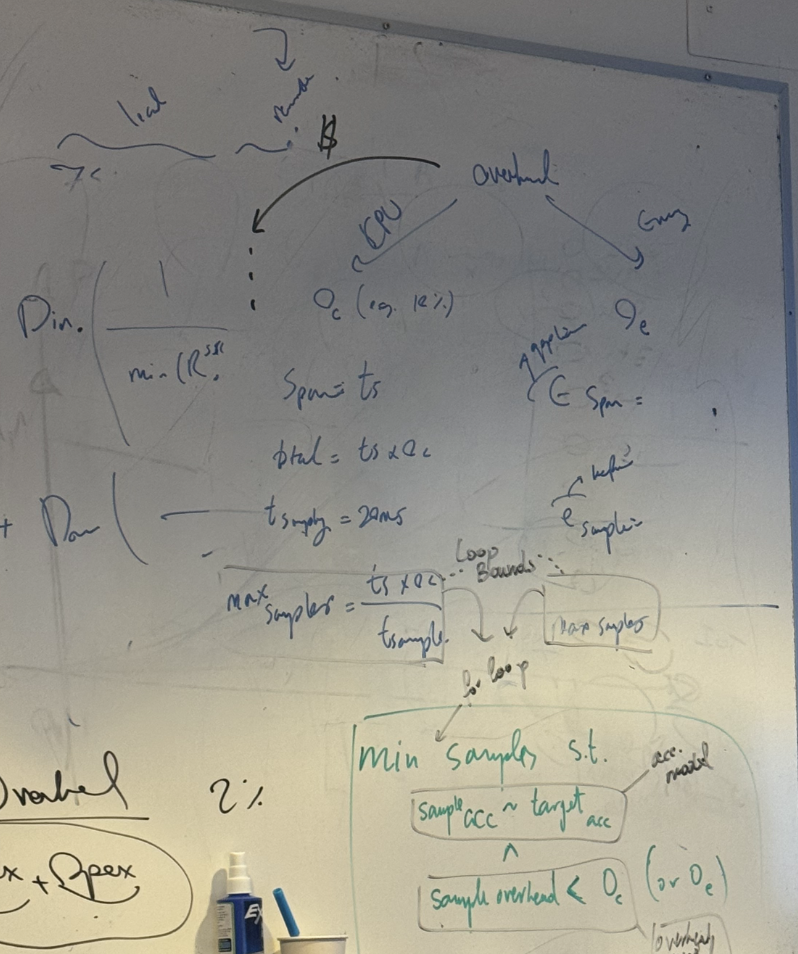

## Using span_total.csv

In [6]:
df_spans_new = pd.read_csv("../../../Data/E2EGHG/span_total.csv")
df_spans_new.columns, df_spans_new.describe()

(Index(['trace_id', 'zone', 'kepler_duration_sum_ms_span', 'energy_joules_span',
        'start_energy_joules_span', 'end_energy_joules_span',
        'energy_start_ts_span', 'energy_end_ts_span', 'exper_name',
        'interval_ms', 'cpu_ms', 'sleep_ms', 'active_interval_ms',
        'idle_scrapping_ms', 'source_csv_span', 'kepler_duration_sum_ms_kepler',
        'energy_joules_kepler', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'energy_start_ts_kepler',
        'energy_end_ts_kepler', 'source_csv_kepler'],
       dtype='object'),
        kepler_duration_sum_ms_span  energy_joules_span  \
 count                 23400.000000        23400.000000   
 mean                    637.661735            4.531829   
 std                     706.129628            4.136577   
 min                      28.392535            0.004777   
 25%                     128.345615            0.871545   
 50%                     310.974976            3.277509   
 75%                     9

### filter down to just span energy, span length, and active interval

In [107]:
# create reduced dataset for modeling
df = df_spans_new.drop(['zone','start_energy_joules_span','end_energy_joules_span','energy_start_ts_span','energy_end_ts_span','exper_name','interval_ms','sleep_ms',
                  'idle_scrapping_ms','source_csv_span','kepler_duration_sum_ms_kepler','start_energy_joules_kepler','end_energy_joules_kepler',
                  'energy_start_ts_kepler','energy_end_ts_kepler','source_csv_kepler','kepler_duration_sum_ms_span','energy_joules_kepler'], axis=1)
df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00000
1,000334742dba29dfc46afb787594b601,10.230748,2500.0,7.81250
2,00059b5722eb69e95bd1ba92e0f73c45,11.861552,3000.0,1.17188
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50000
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25000
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00000
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50000
7,002047c7de17eeb552c3b692f87bfcea,8.722139,2500.0,250.00000
8,00241845acfb5abe064cad3b4ebbfa20,2.698461,750.0,0.29297
9,00246bd3ff8c029bbeba76e3952cc685,7.461335,2000.0,200.00000


### get mean E for each cpu_ms

In [55]:
#df[['energy_joules_span','cpu_ms']]

In [108]:
df_e_cpu = df[['energy_joules_span','cpu_ms']].copy()
df_e_cpu = df_e_cpu.groupby(['cpu_ms'], as_index=False).mean()
df_e_cpu

,cpu_ms,energy_joules_span
0,20.0,0.057852
1,50.0,0.152884
2,100.0,0.316816
3,150.0,0.505404
4,250.0,0.896935
5,375.0,1.407906
6,500.0,1.915680
7,625.0,2.432213
8,750.0,2.899355
9,1000.0,3.966976


#### energy vs span length quite linear

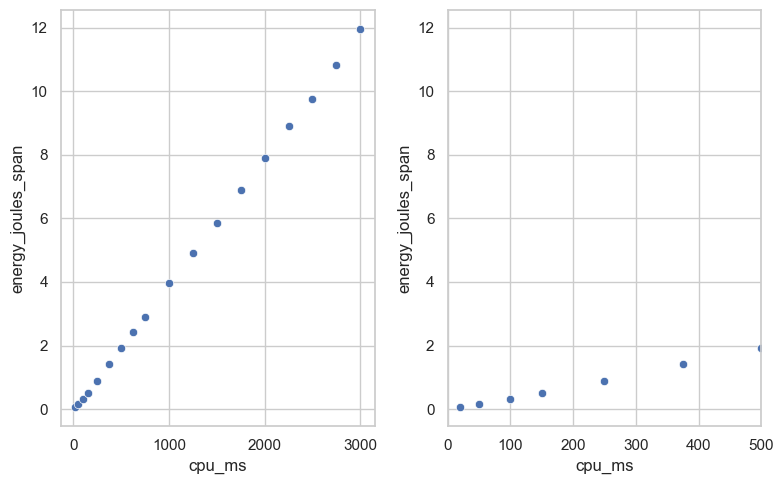

In [109]:
plt.figure(figsize=(8,5))
plt.subplot(121)
sns.scatterplot(data=df_e_cpu, x='cpu_ms', y='energy_joules_span')
plt.subplot(122)
sns.scatterplot(data=df_e_cpu, x='cpu_ms', y='energy_joules_span')
plt.xlim(0,500)
plt.tight_layout()
plt.show()

### add column with mean energy for that cpu_ms

In [110]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'mean_energy_cpu_ms'] = df_e_cpu[df_e_cpu['cpu_ms'] == i].energy_joules_span.values[0]

df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00000,3.966976
1,000334742dba29dfc46afb787594b601,10.230748,2500.0,7.81250,9.755328
2,00059b5722eb69e95bd1ba92e0f73c45,11.861552,3000.0,1.17188,11.957937
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50000,8.910616
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25000,4.923006
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00000,9.755328
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50000,2.899355
7,002047c7de17eeb552c3b692f87bfcea,8.722139,2500.0,250.00000,9.755328
8,00241845acfb5abe064cad3b4ebbfa20,2.698461,750.0,0.29297,2.899355
9,00246bd3ff8c029bbeba76e3952cc685,7.461335,2000.0,200.00000,7.898235


### deviation for trace E from mean for that cpu_ms

In [111]:
df['energy_devation'] = (df.mean_energy_cpu_ms - df.energy_joules_span) 

### and % deviation from mean for that cpu_ms, sampling ratio, and accuracy columns
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [144]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.mean_energy_cpu_ms

In [145]:
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)
df['energy_accuracy_abs'] = 1 - df.energy_deviation_pct_abs/100

#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [146]:
df_filtered = df.query('active_interval_ms >= 25.0')
df_filtered

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00,3.966976,-0.335032,-8.445529,1.333333,8.445529,0.915545
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50,8.910616,1.403243,15.747989,1.333333,15.747989,0.842520
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25,4.923006,0.332048,6.744820,40.000000,6.744820,0.932552
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00,9.755328,2.846412,29.178021,2.000000,29.178021,0.708220
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50,2.899355,-0.602263,-20.772316,1.333333,20.772316,0.792277
...,...,...,...,...,...,...,...,...,...,...
23394,fff7bafb31ab667bba9f152aee52d491,1.459945,375.0,375.00,1.407906,-0.052039,-3.696205,1.000000,3.696205,0.963038
23395,fff9346ba846f0ad7819fd23178da0d6,3.730332,1000.0,1000.00,3.966976,0.236644,5.965348,1.000000,5.965348,0.940347
23396,fff96f67c1566bb89cb5ddd314dce6d9,3.570326,1000.0,50.00,3.966976,0.396650,9.998798,20.000000,9.998798,0.900012
23398,fffa7632c38ad5e70e5d438ba99afc84,2.140912,625.0,468.75,2.432213,0.291301,11.976797,1.333333,11.976797,0.880232


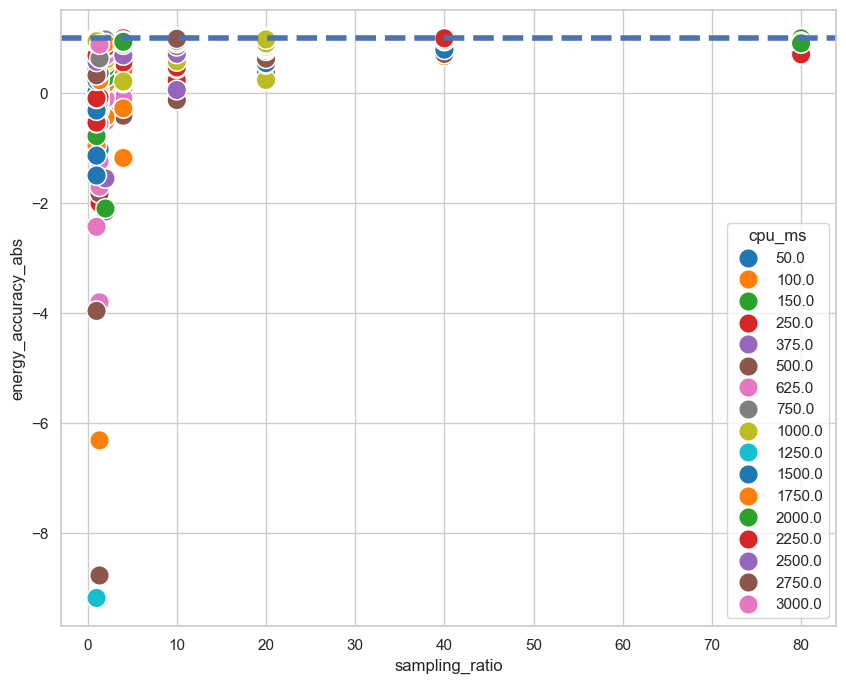

In [147]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', s=200, palette='tab10')
plt.axhline(y = 1, linestyle='--', linewidth=4)
#sns.lineplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', palette='tab10')

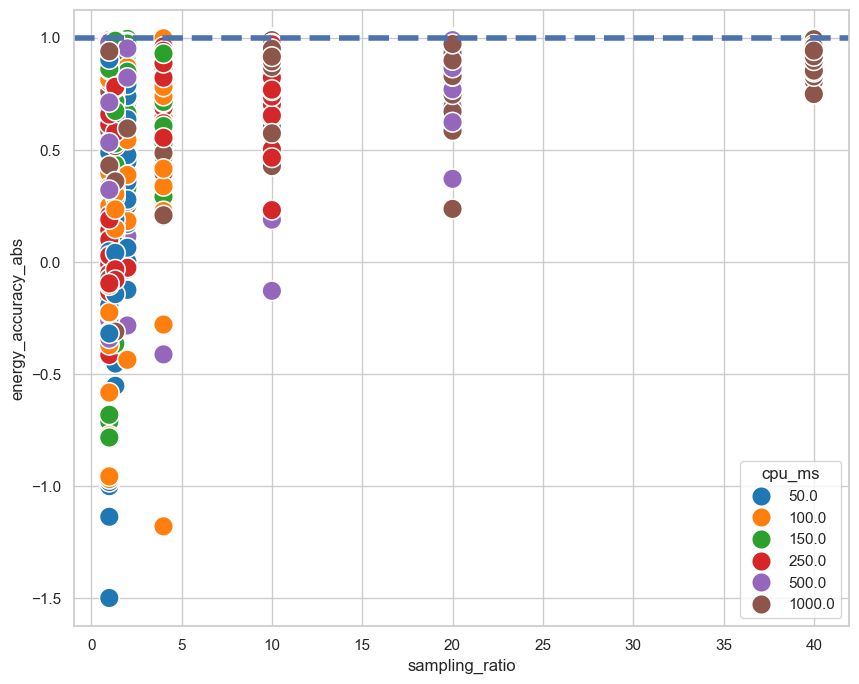

In [148]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', s=200, palette='tab10')
plt.axhline(y = 1, linestyle='--', linewidth=4)
#sns.lineplot(data=df_filtered, x='sampling_ratio', y='energy_accuracy_abs', hue='cpu_ms', palette='tab10')

(-3.0, 1.5)

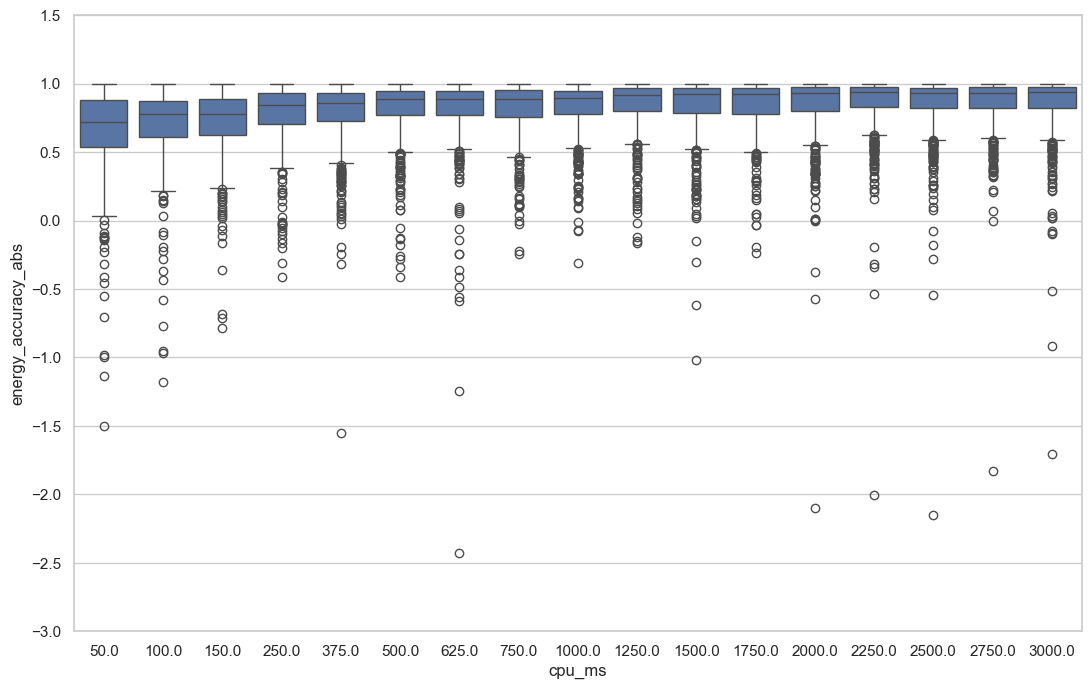

In [149]:
plt.figure(figsize=(13,8))
sns.boxplot(data = df_filtered, x='cpu_ms', y='energy_accuracy_abs')
plt.ylim(-3,1.5)
#plt.axhline(y=0.10, linestyle="--", linewidth=2)

Text(0, 0.5, 'Energy Accuracy: max = 1 (100%)')

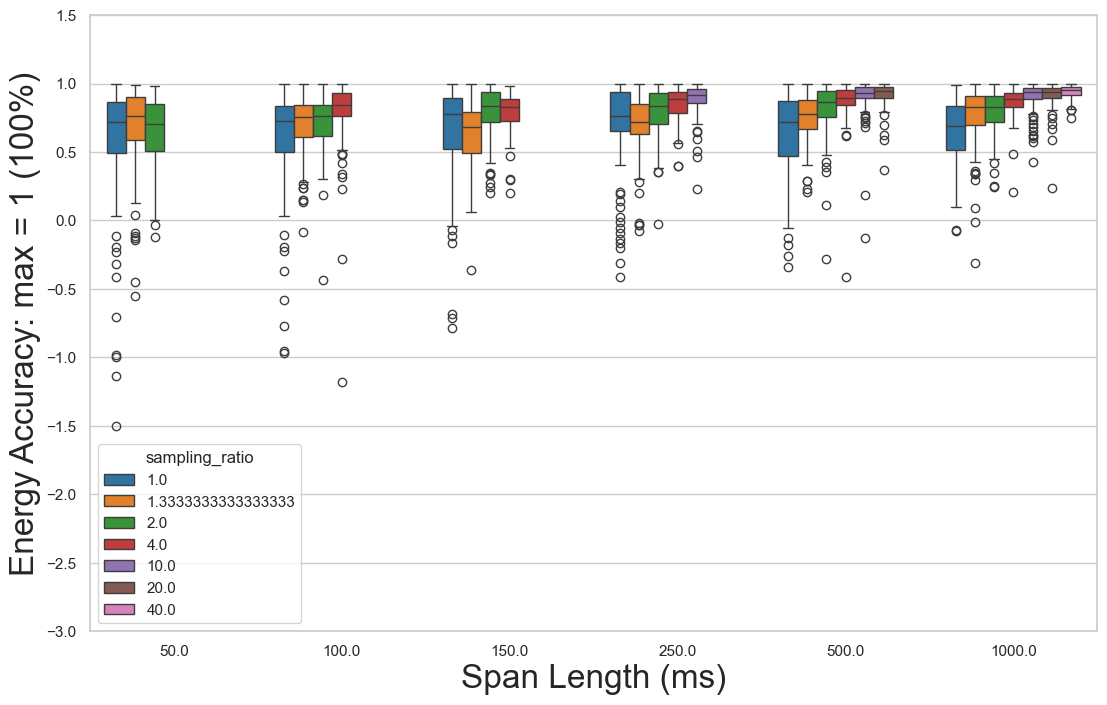

In [150]:
plt.figure(figsize=(13,8))
sns.boxplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_accuracy_abs', hue='sampling_ratio', palette='tab10')
plt.ylim(-3,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Accuracy: max = 1 (100%)", fontsize=fs)
#plt.axhline(y=0.10, linestyle="--", linewidth=2)

#### boxenplot with outliers removed

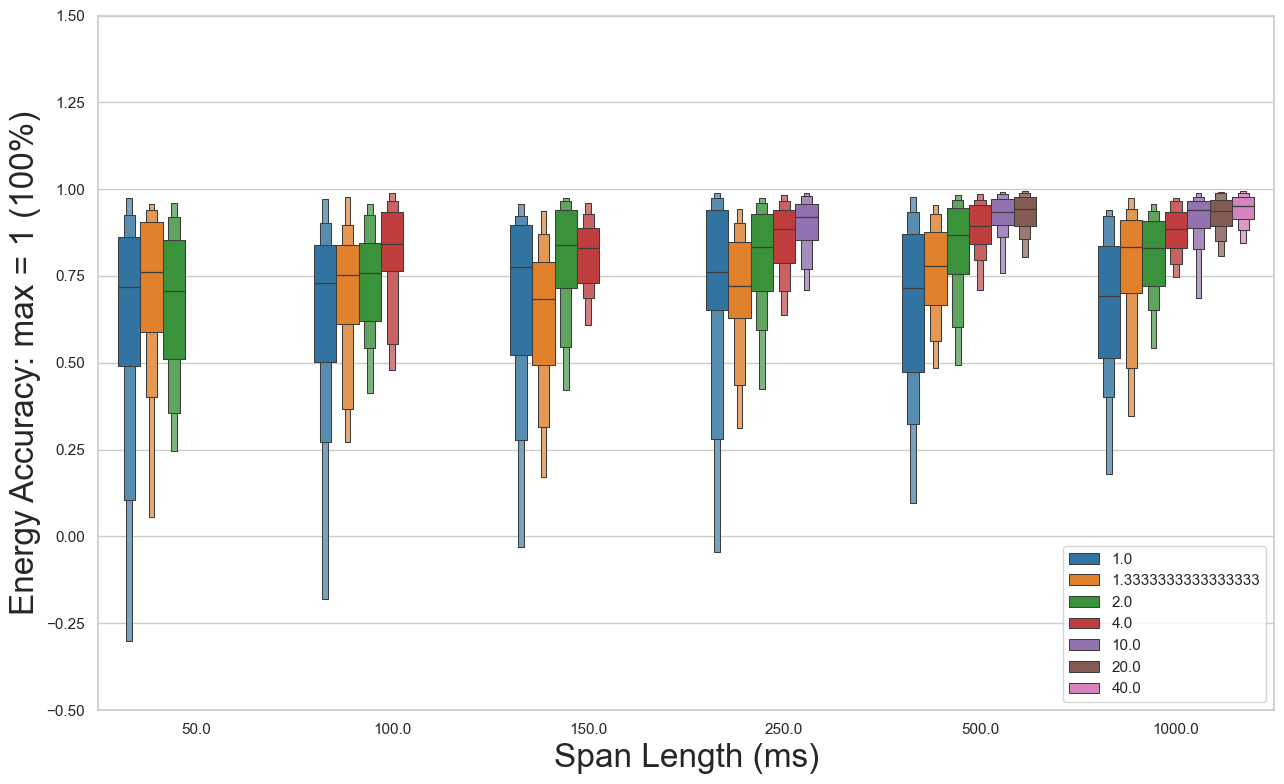

In [151]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_accuracy_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
plt.ylim(-0.5,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Accuracy: max = 1 (100%)", fontsize=fs)
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.show()

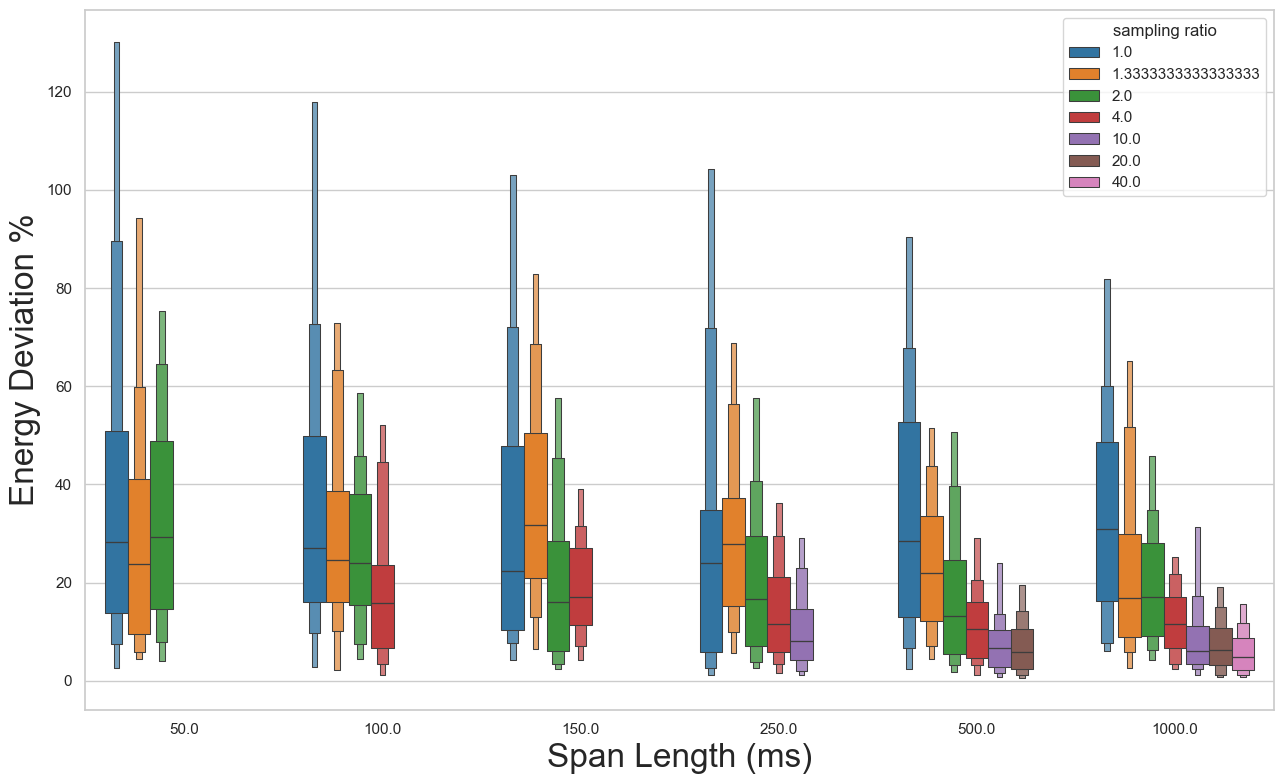

In [154]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000])'), x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.tight_layout()
plt.show()

#### Show all span lengths

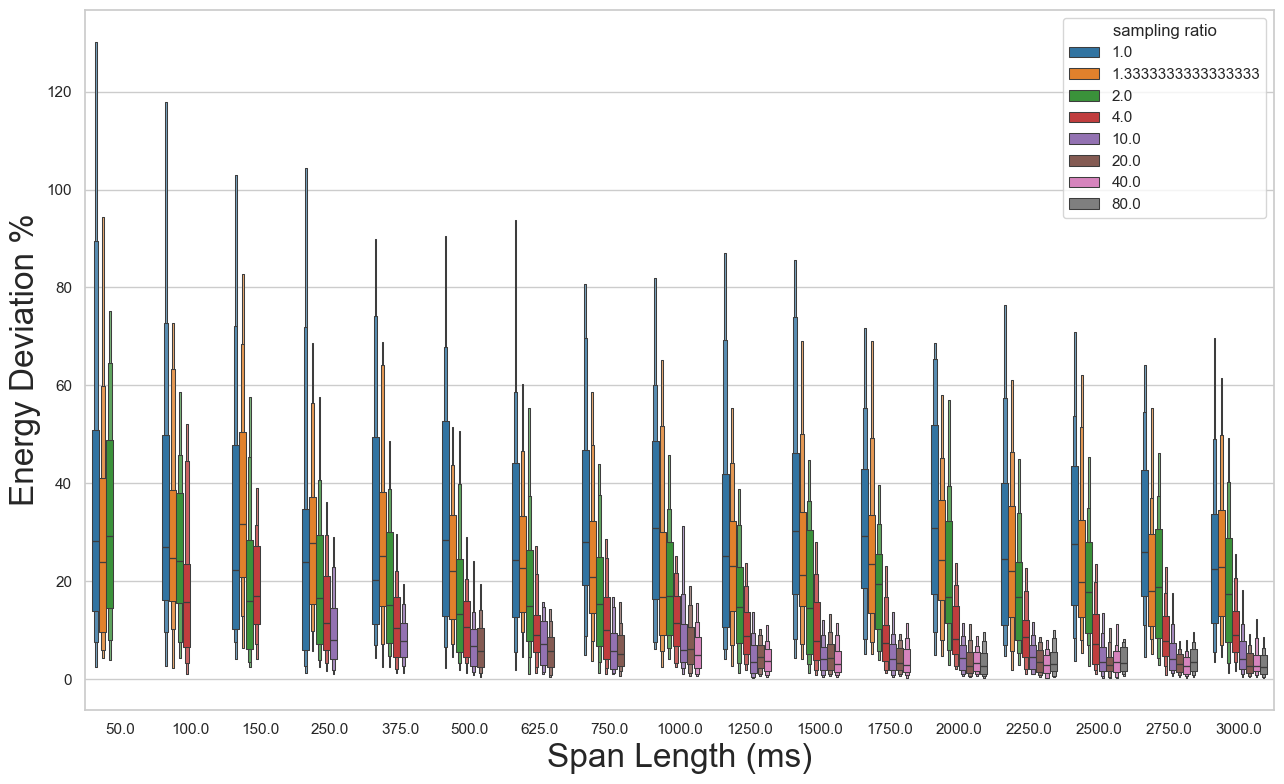

In [156]:
plt.figure(figsize=(13,8))
sns.boxenplot(data = df_filtered, x='cpu_ms', y='energy_deviation_pct_abs', hue='sampling_ratio', palette='tab10', showfliers=False)
#plt.ylim(0,1.5)
plt.xlabel("Span Length (ms)", fontsize=fs)
plt.ylabel("Energy Deviation %", fontsize=fs)
plt.legend(loc = 'upper right', title='sampling ratio')
plt.tight_layout()
plt.show()

### As expected from our other testing, accuracy improves with more sampling

### Probably should look at median or mean accuracy for a given sampling ratio for each span length

In [277]:
df_filtered

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,mean_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,energy_accuracy_abs
0,0001d56235a6f9ae9811f804969a2283,4.302008,1000.0,750.00,3.966976,-0.335032,-8.445529,1.333333,8.445529,0.915545
3,0005f47df5543381d3fc756117ea74dd,7.507373,2250.0,1687.50,8.910616,1.403243,15.747989,1.333333,15.747989,0.842520
4,0006b8816a45fdc0a9f56d42ac50c321,4.590958,1250.0,31.25,4.923006,0.332048,6.744820,40.000000,6.744820,0.932552
5,0011b52ff1661d067ca42fab41ab1c38,6.908916,2500.0,1250.00,9.755328,2.846412,29.178021,2.000000,29.178021,0.708220
6,001d8501a50572c42c454110595cb1ca,3.501618,750.0,562.50,2.899355,-0.602263,-20.772316,1.333333,20.772316,0.792277
...,...,...,...,...,...,...,...,...,...,...
23394,fff7bafb31ab667bba9f152aee52d491,1.459945,375.0,375.00,1.407906,-0.052039,-3.696205,1.000000,3.696205,0.963038
23395,fff9346ba846f0ad7819fd23178da0d6,3.730332,1000.0,1000.00,3.966976,0.236644,5.965348,1.000000,5.965348,0.940347
23396,fff96f67c1566bb89cb5ddd314dce6d9,3.570326,1000.0,50.00,3.966976,0.396650,9.998798,20.000000,9.998798,0.900012
23398,fffa7632c38ad5e70e5d438ba99afc84,2.140912,625.0,468.75,2.432213,0.291301,11.976797,1.333333,11.976797,0.880232


#### checking distibution of span energy for a given cpu_ms

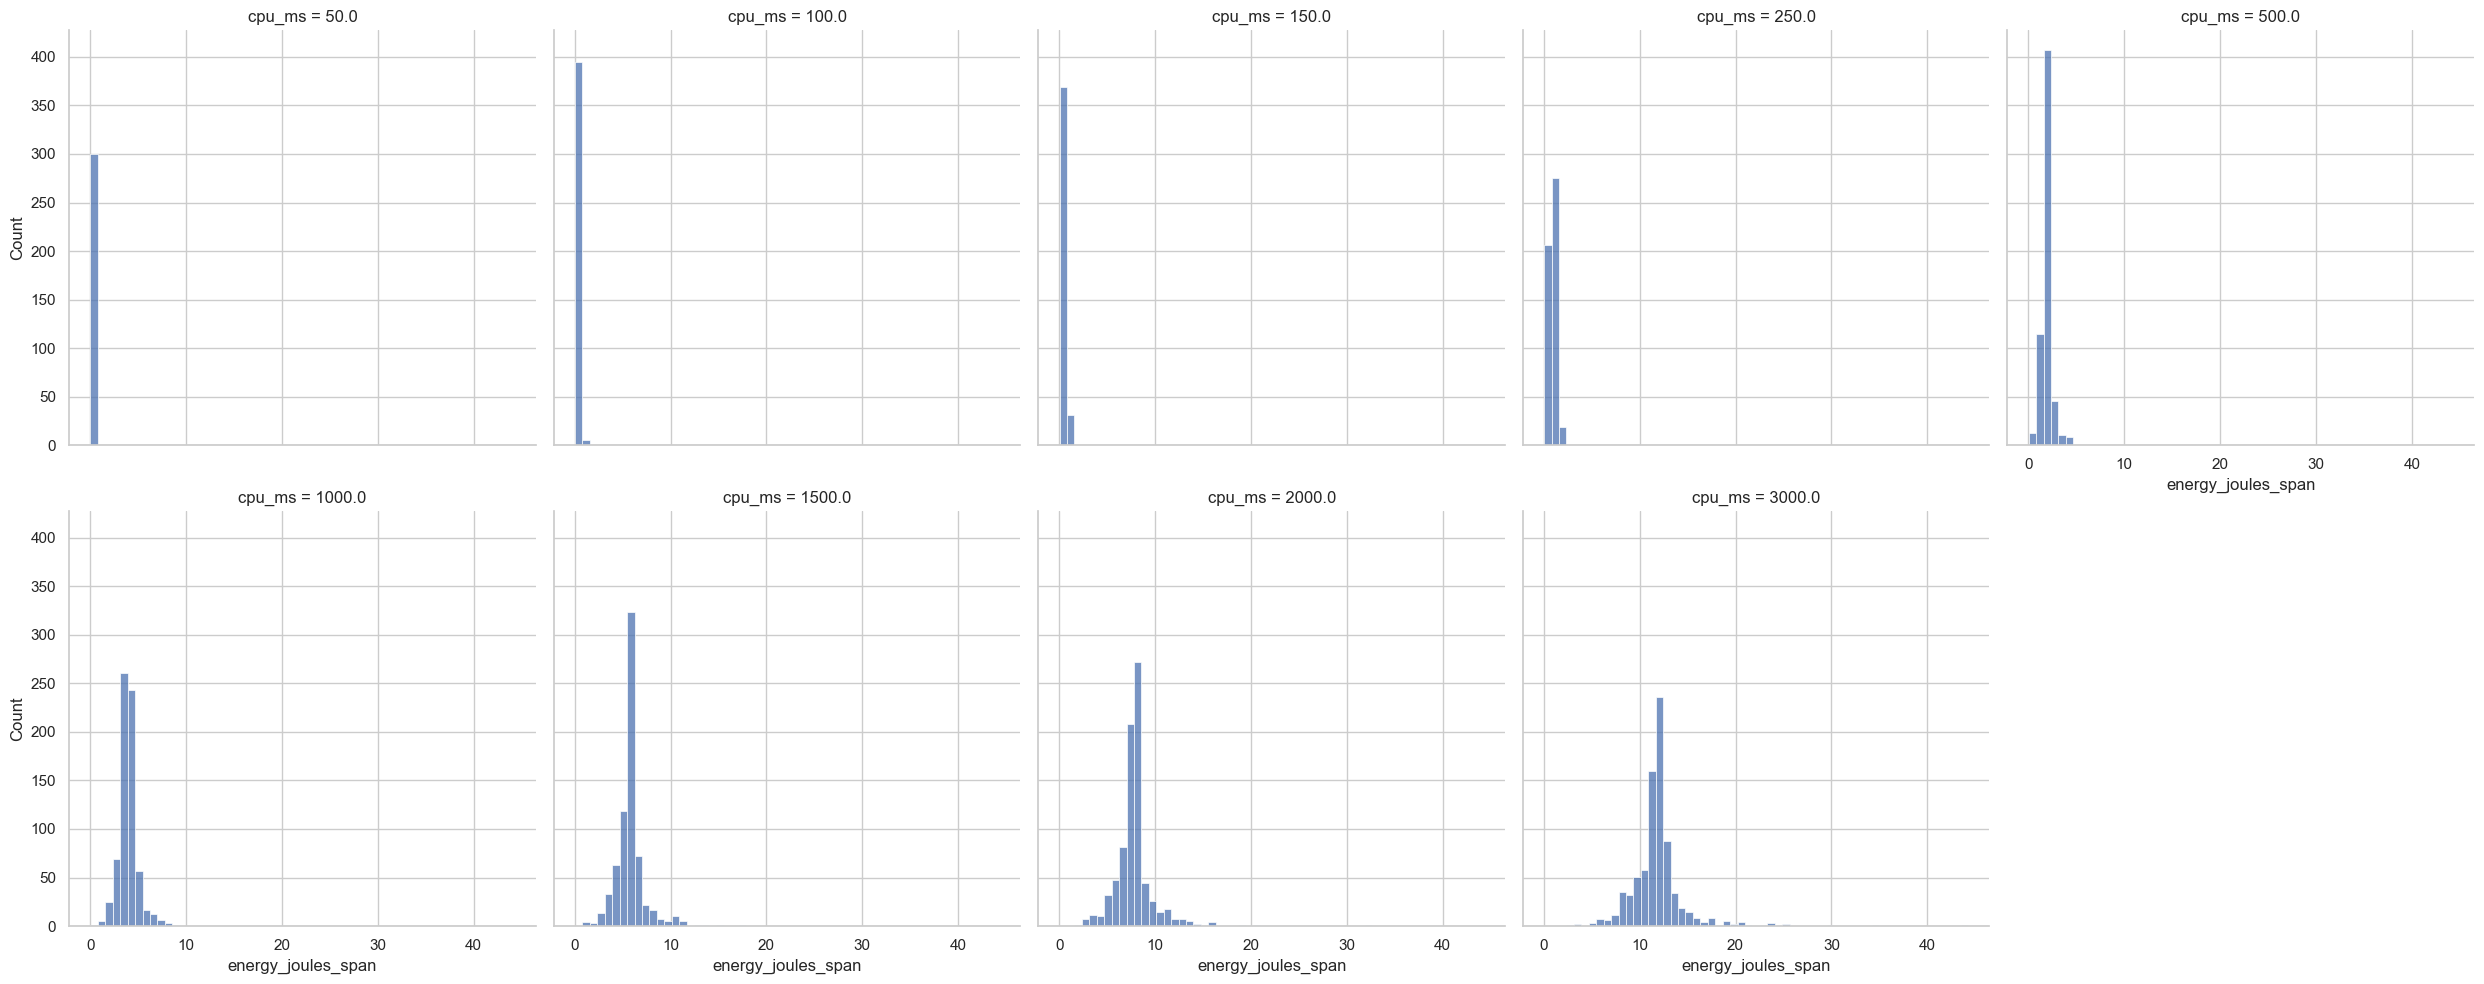

In [278]:
# checking distibution of span energy for a given cpu_ms
sns.displot(df_filtered.query('cpu_ms.isin([50,100,150,250,500,1000,1500,2000,3000])'), x='energy_joules_span', col='cpu_ms', col_wrap=5)
#plt.xlim(0,10)

#### Fairly normal - gather statistics

In [279]:
df_mean_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).mean()
df_std_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()
# not needed because count = 100 for each sampling ratio for each cpu_ms
#df_count_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).count()
df_mean_dev = df_mean_dev.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'mean_energy_deviation'})
df_mean_dev['std_energy_deviation'] = df_std_dev['energy_deviation_pct_abs']
#df_mean_dev
df_mean_dev['conf_int_95'] = 1.96 * df_mean_dev.std_energy_deviation / np.sqrt(100)
df_mean_dev

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95
0,50.0,1.000000,43.005437,48.477860,9.501661
1,50.0,1.333333,31.890456,31.275841,6.130065
2,50.0,2.000000,34.346073,24.856768,4.871926
3,100.0,1.000000,39.958558,40.226712,7.884436
4,100.0,1.333333,30.899346,22.663956,4.442135
...,...,...,...,...,...
102,3000.0,4.000000,11.577594,12.181633,2.387600
103,3000.0,10.000000,6.230378,6.477078,1.269507
104,3000.0,20.000000,3.796954,3.662921,0.717933
105,3000.0,40.000000,4.292804,4.626332,0.906761


<ErrorbarContainer object of 3 artists>

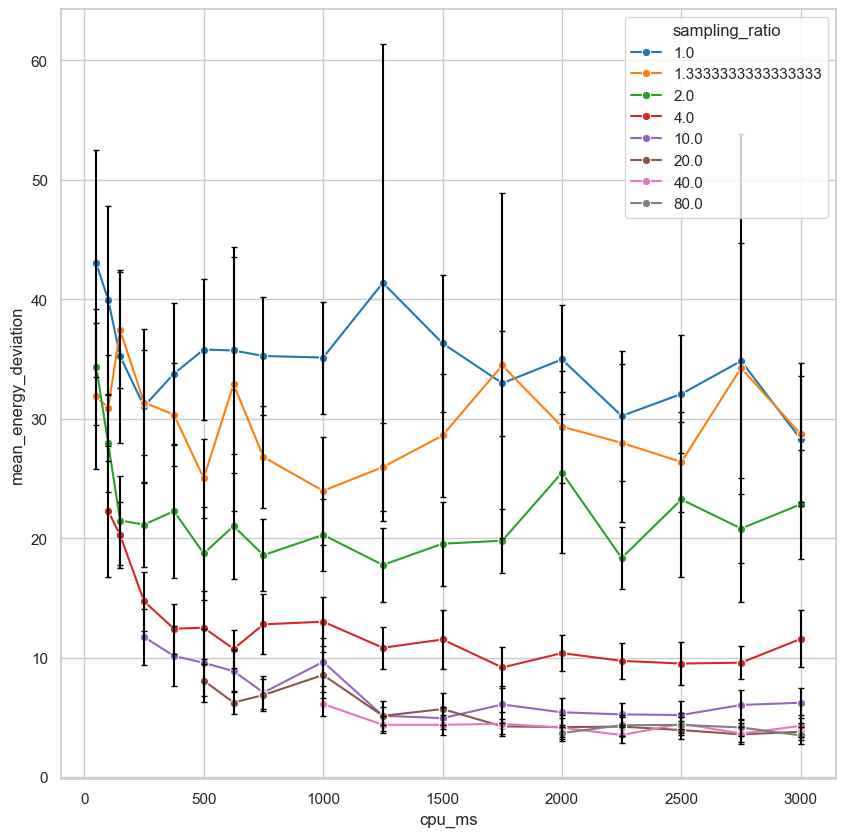

In [280]:
plt.figure(figsize=(10,10))
sns.lineplot(data=df_mean_dev, x='cpu_ms', y='mean_energy_deviation', hue='sampling_ratio', palette='tab10', marker='o')
plt.errorbar(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_deviation'], yerr=df_mean_dev['conf_int_95'], fmt='none', capsize=2,color='black')
# plt.fill_between(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'] - df_mean_dev['conf_int_95'],
#                  df_mean_dev['mean_energy_devation'] + df_mean_dev['conf_int_95'], alpha=0.2)

<Figure size 1000x1000 with 0 Axes>

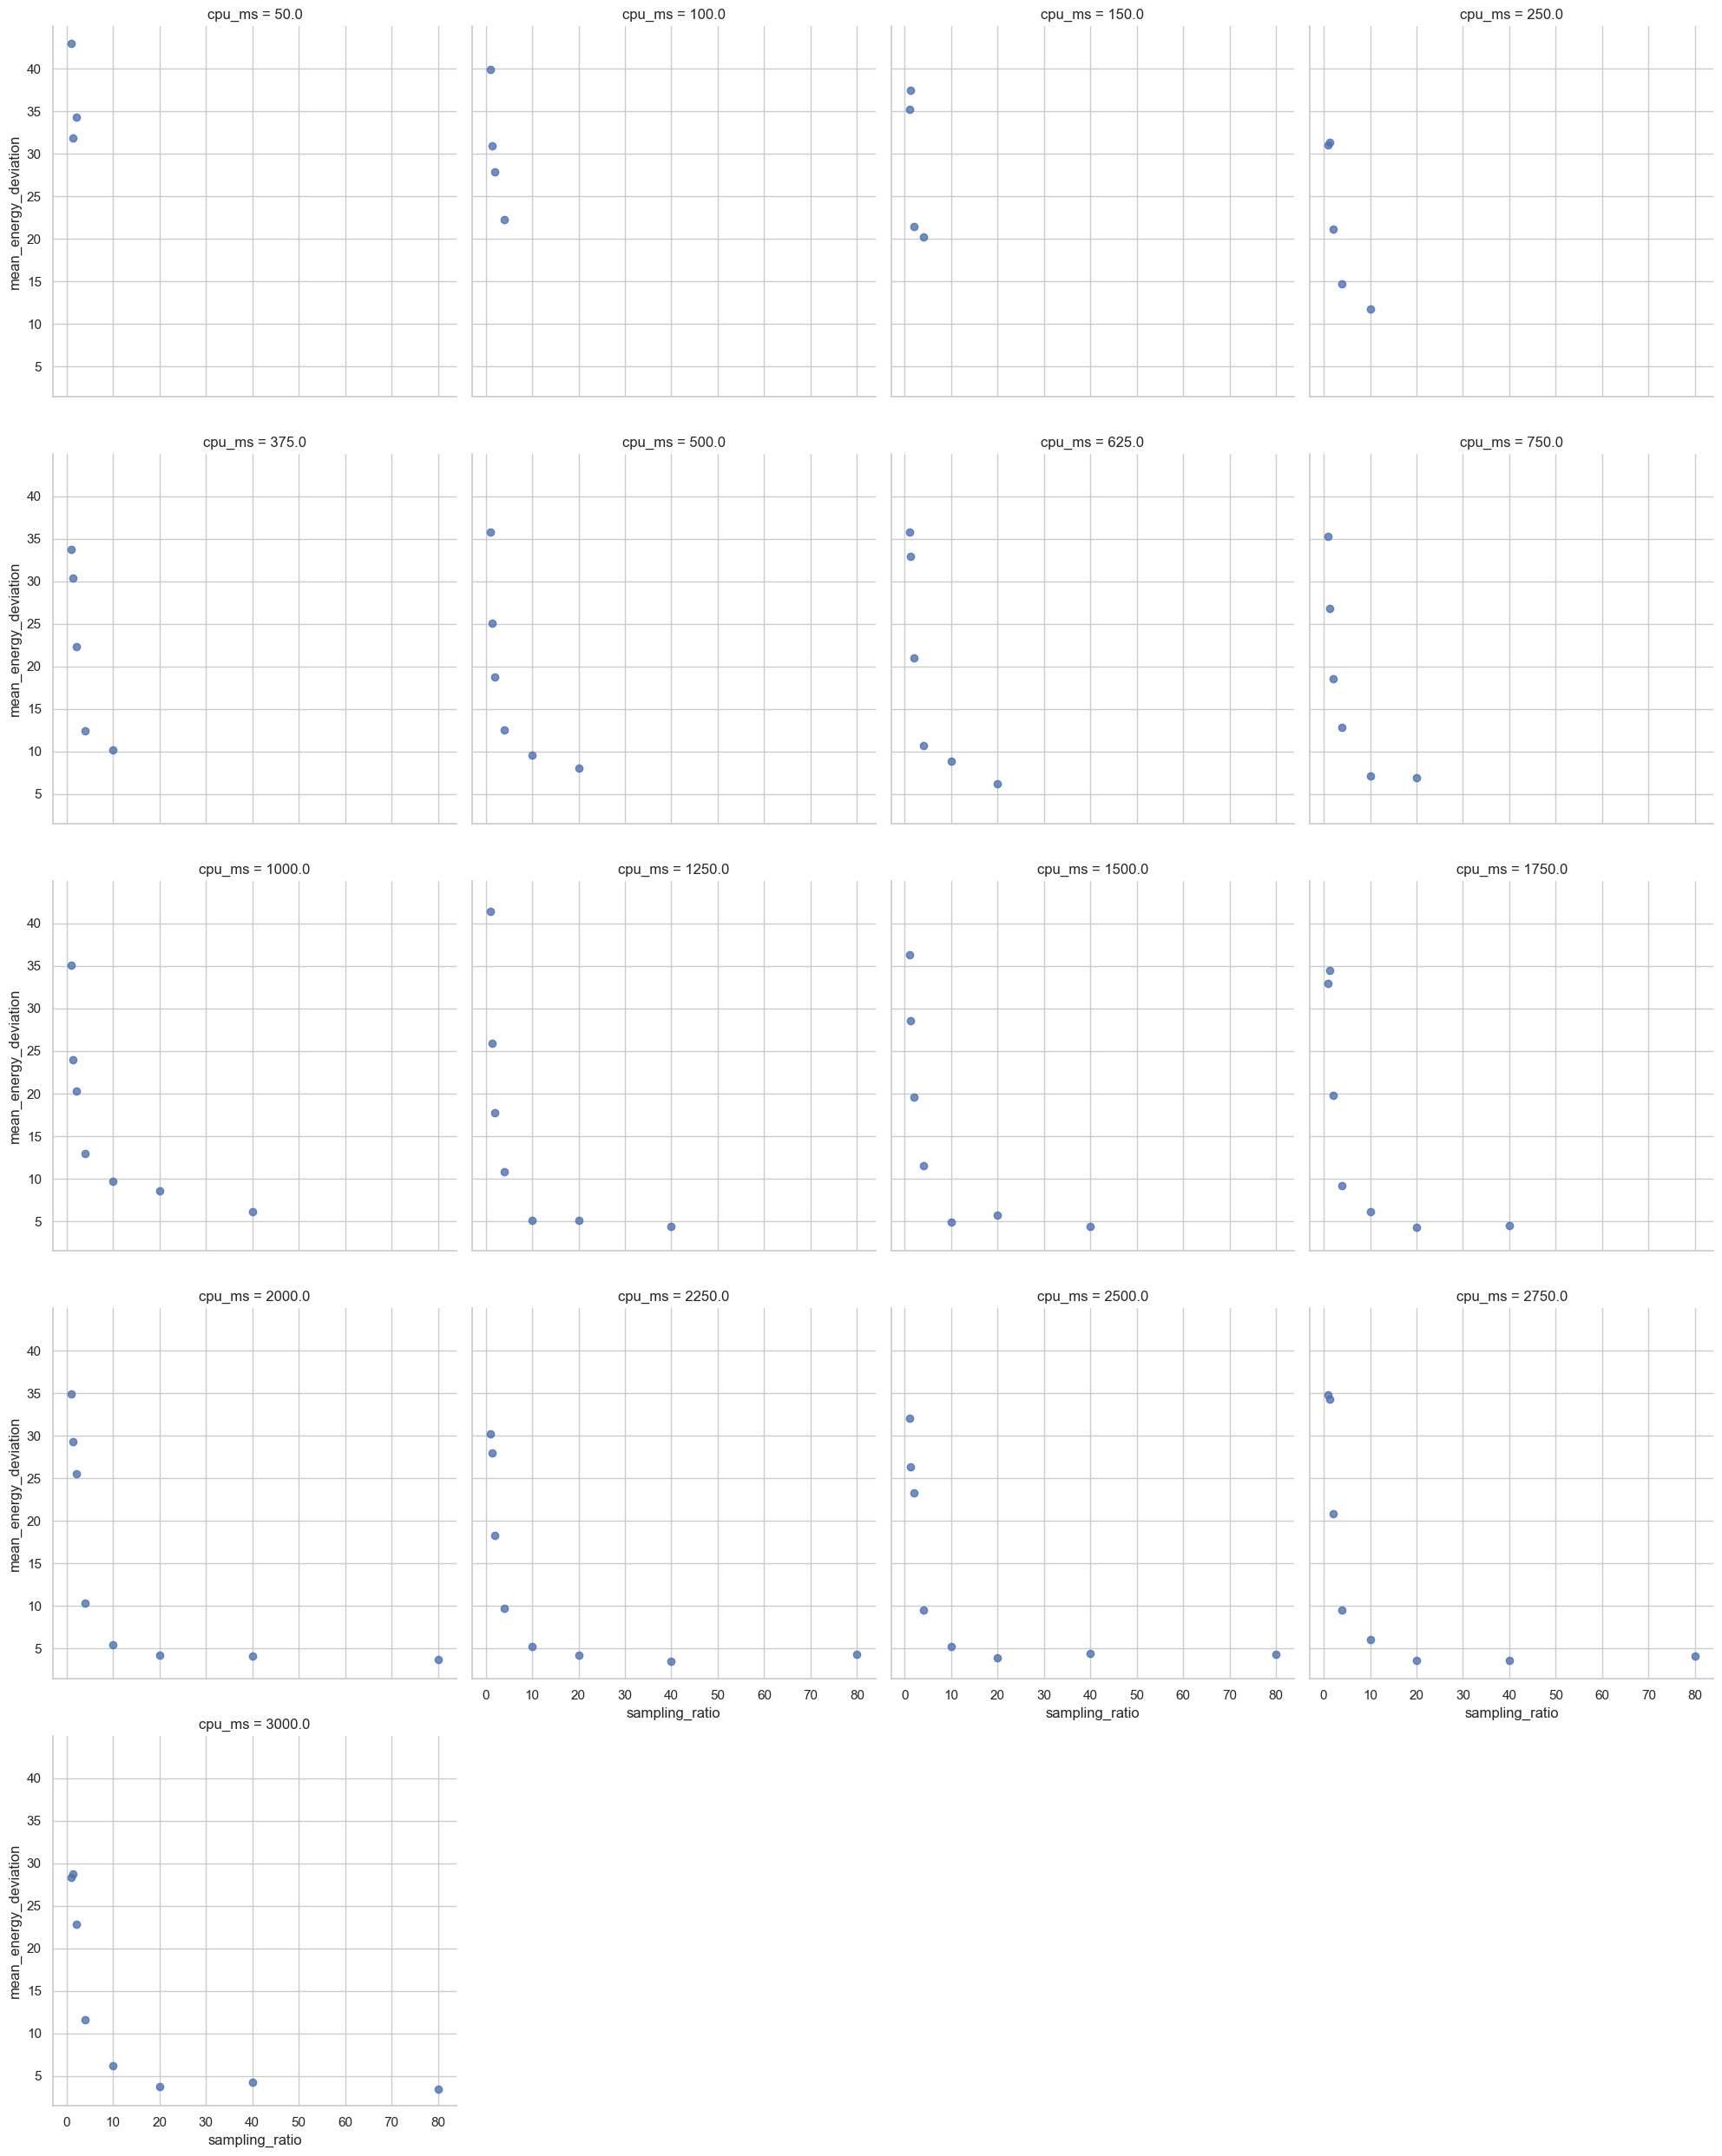

In [281]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev, x='sampling_ratio', y='mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', fit_reg=False)

### use log of energy?

In [282]:
df_mean_dev_log = df_mean_dev.copy()
df_mean_dev_log['log_mean_energy_deviation'] = np.log(df_mean_dev_log['mean_energy_deviation'])
df_mean_dev_log['log_sampling_ratio'] = np.log(df_mean_dev_log['sampling_ratio'])
df_mean_dev_log['recip_sampling_ratio'] = 1 / df_mean_dev_log['sampling_ratio']
df_mean_dev_log

,cpu_ms,sampling_ratio,mean_energy_deviation,std_energy_deviation,conf_int_95,log_mean_energy_deviation,log_sampling_ratio,recip_sampling_ratio
0,50.0,1.000000,43.005437,48.477860,9.501661,3.761327,0.000000,1.0000
1,50.0,1.333333,31.890456,31.275841,6.130065,3.462307,0.287682,0.7500
2,50.0,2.000000,34.346073,24.856768,4.871926,3.536488,0.693147,0.5000
3,100.0,1.000000,39.958558,40.226712,7.884436,3.687843,0.000000,1.0000
4,100.0,1.333333,30.899346,22.663956,4.442135,3.430735,0.287682,0.7500
...,...,...,...,...,...,...,...,...
102,3000.0,4.000000,11.577594,12.181633,2.387600,2.449072,1.386294,0.2500
103,3000.0,10.000000,6.230378,6.477078,1.269507,1.829437,2.302585,0.1000
104,3000.0,20.000000,3.796954,3.662921,0.717933,1.334199,2.995732,0.0500
105,3000.0,40.000000,4.292804,4.626332,0.906761,1.456940,3.688879,0.0250


Text(33.28125, 0.5, 'log(mean energy deviation')

<Figure size 1000x1000 with 0 Axes>

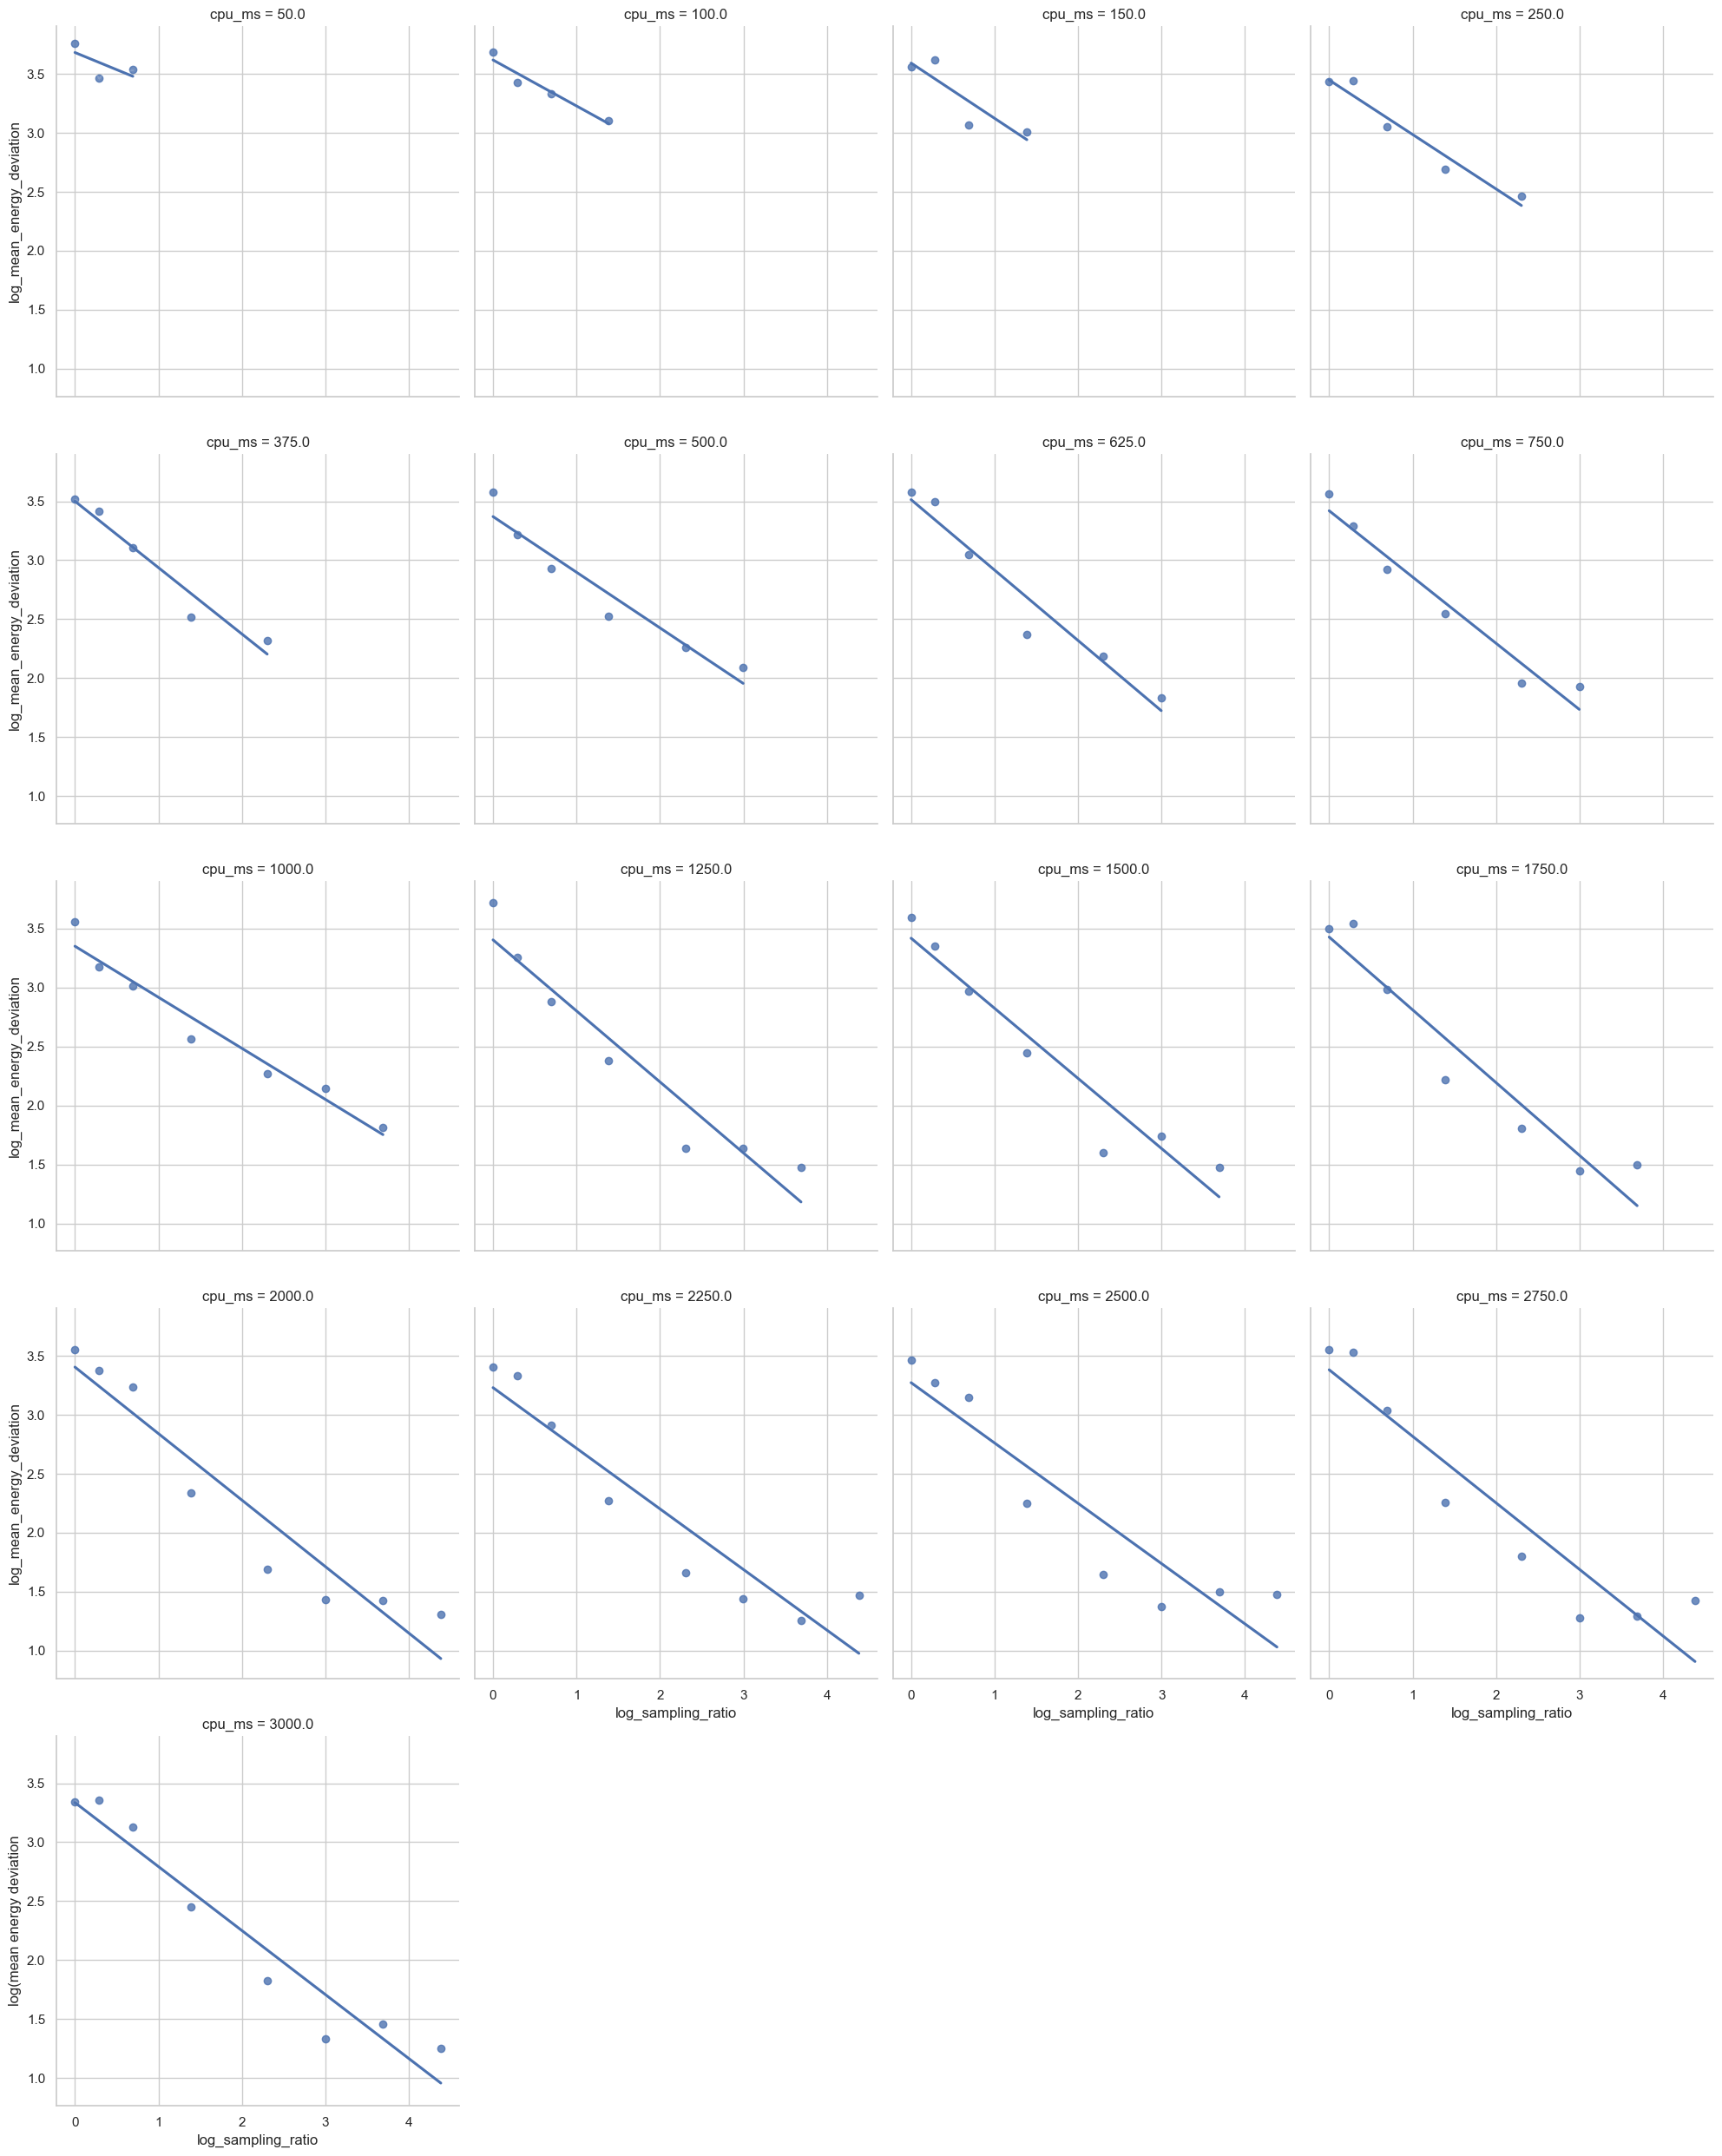

In [283]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev_log, x='log_sampling_ratio', y='log_mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=0)
plt.ylabel("log(mean energy deviation")
#plt.errorbar(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'], yerr=np.log(df_mean_dev['conf_int_95']), fmt='none', capsize=2,color='black')
# plt.fill_between(df_mean_dev['cpu_ms'], df_mean_dev['mean_energy_devation'] - df_mean_dev['conf_int_95'],
#                  df_mean_dev['mean_energy_devation'] + df_mean_dev['conf_int_95'], alpha=0.2)

#### 1/sampling_ratio

<Figure size 1000x1000 with 0 Axes>

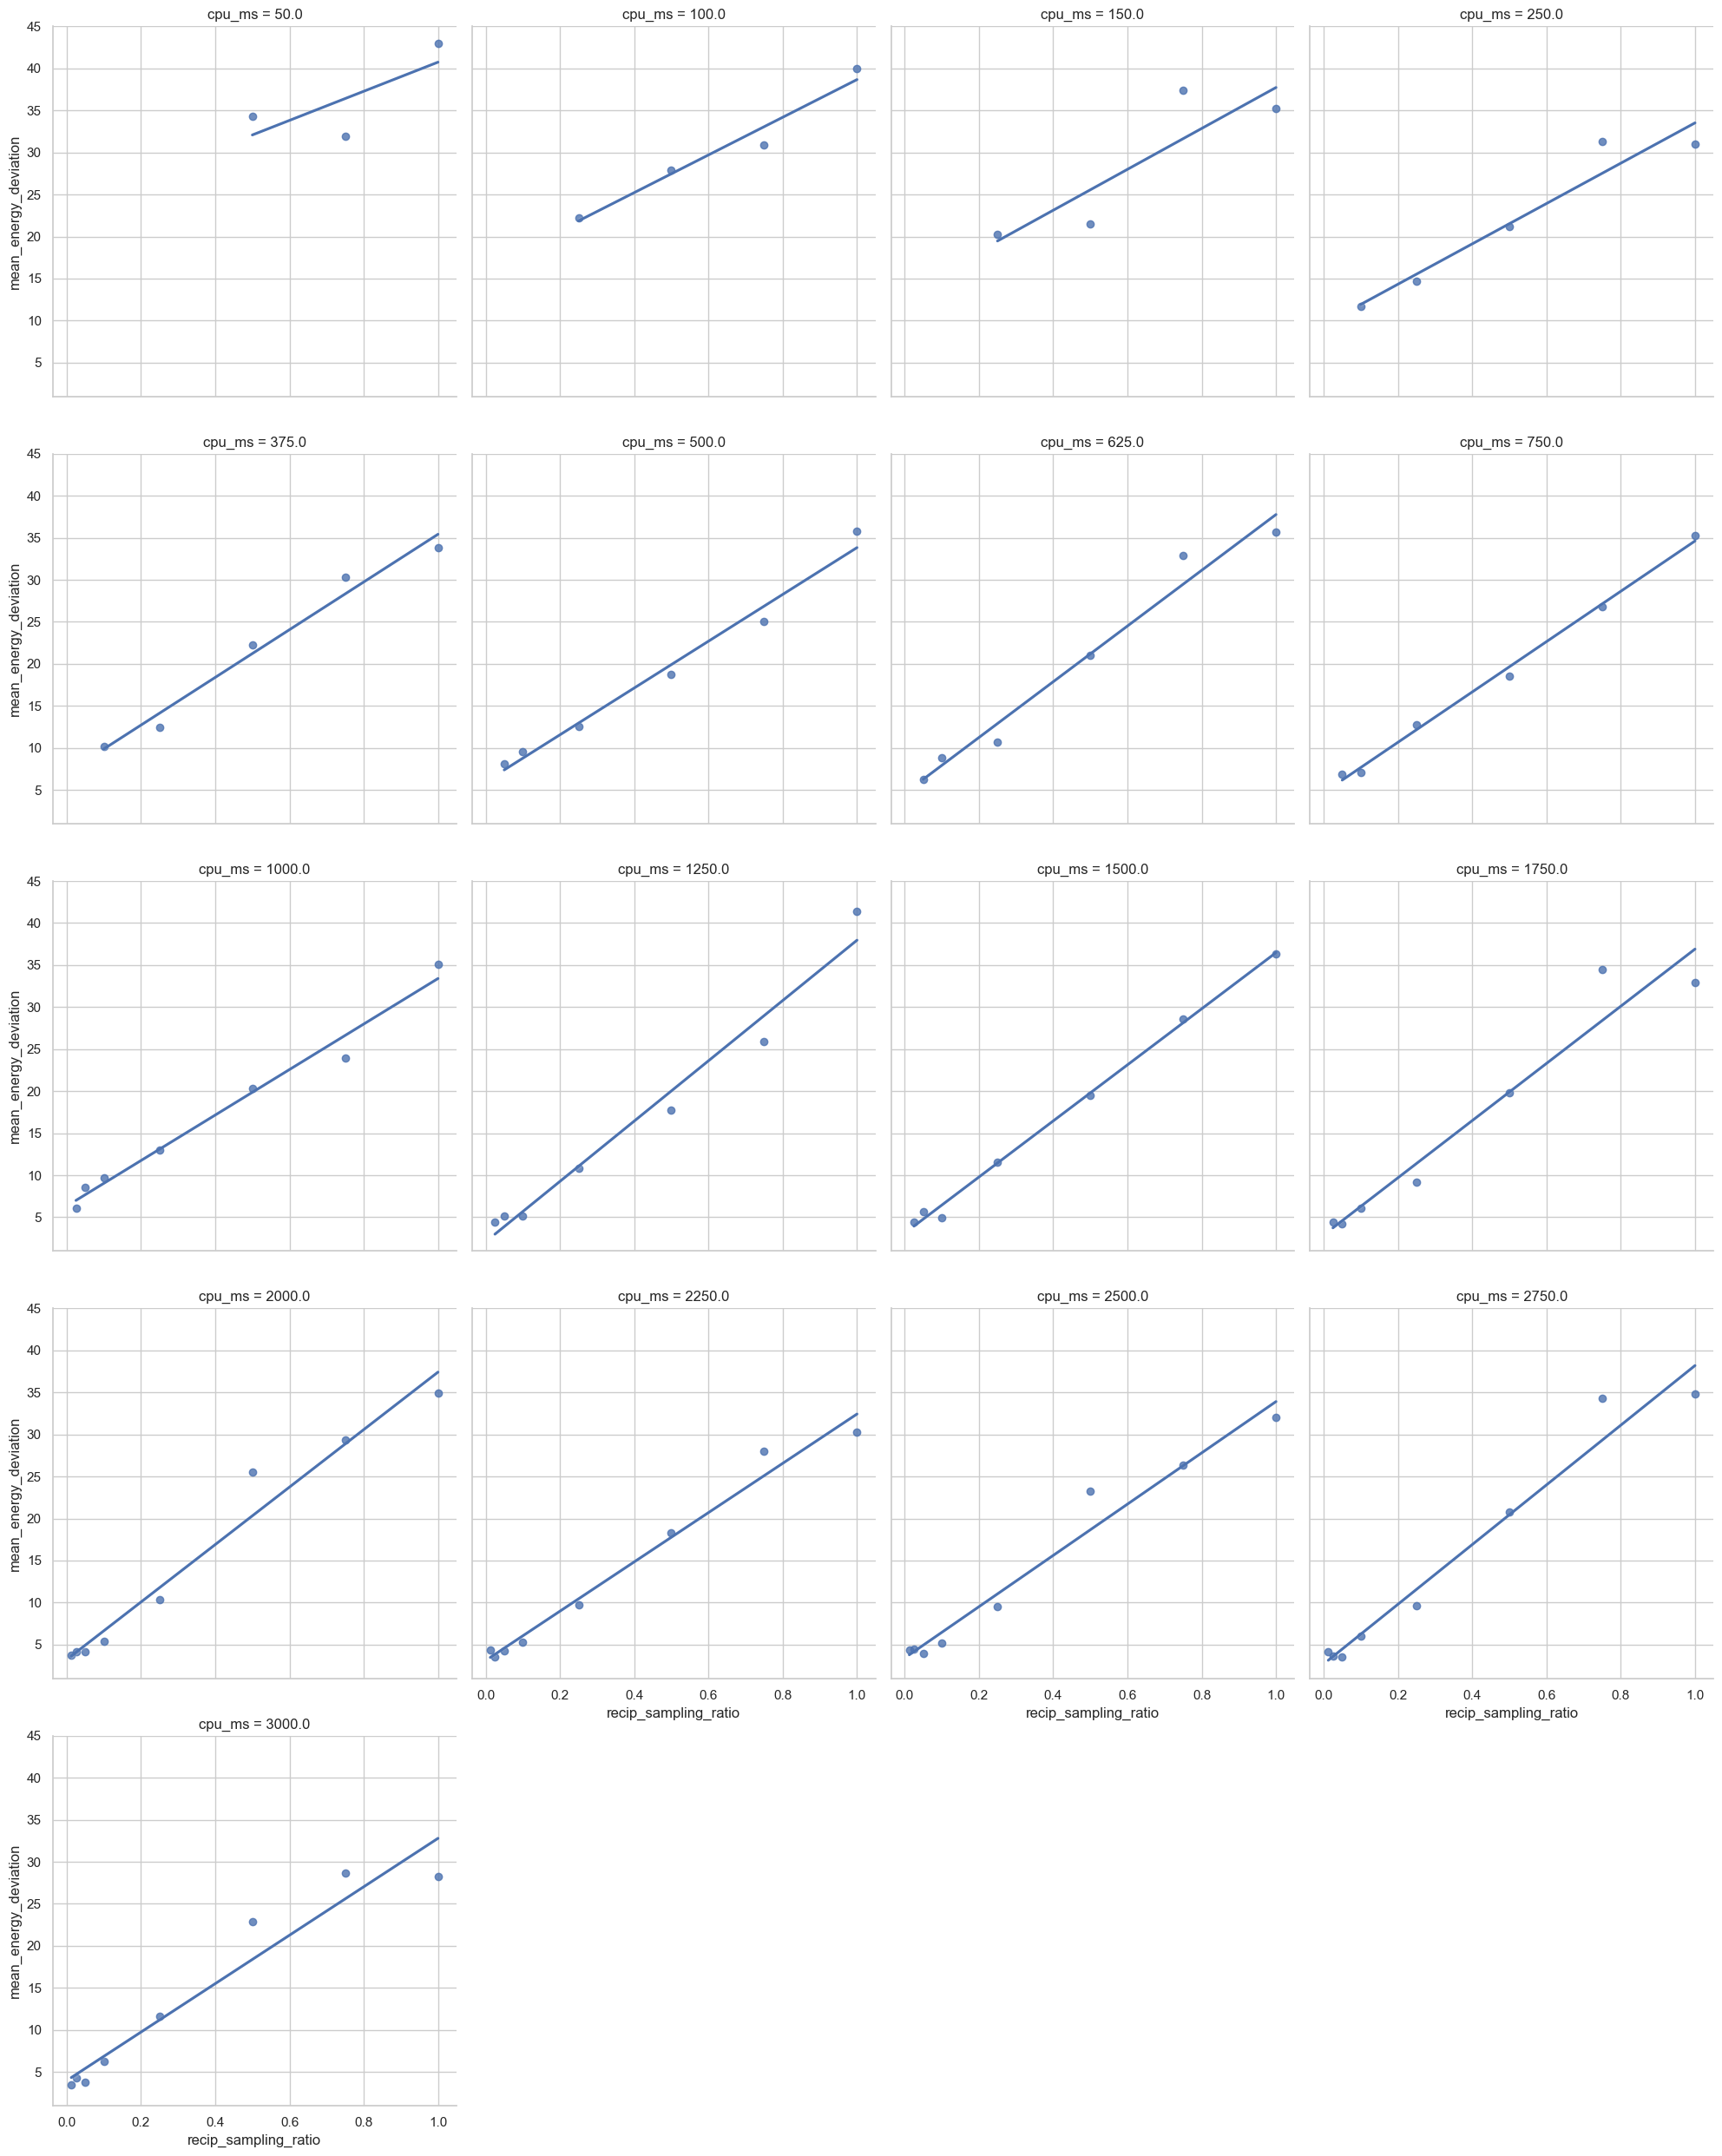

In [284]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_mean_dev_log, x='recip_sampling_ratio', y='mean_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=0)
#plt.ylabel("log(mean energy deviation")

Text(42.06116210937499, 0.5, '% Deviation from Mean E')

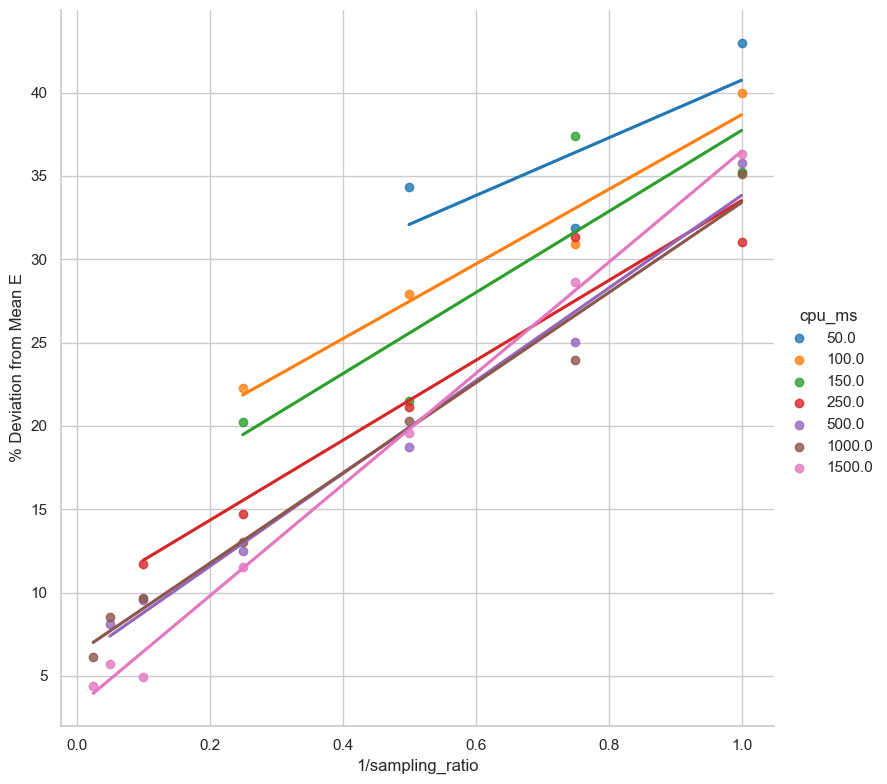

In [285]:
#plt.figure(figsize=(14,14))
sns.lmplot(data=df_mean_dev_log.query('cpu_ms.isin([50,100,150,250,500,1000,1500])'), x='recip_sampling_ratio', y='mean_energy_deviation', hue='cpu_ms', palette='tab10', markers='o', ci=0, height=8)
plt.xlabel("1/sampling_ratio")
plt.ylabel("% Deviation from Mean E")

### Create a simple multi-linear regression model using reciprocal sampling ratio and mean energy deviation

#### restrict to spans <= 1000 ms

In [286]:
df_mean_dev['recip_sampling_ratio'] = 1 / df_mean_dev['sampling_ratio']

In [382]:
df_mean_dev.columns

Index(['cpu_ms', 'sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95', 'recip_sampling_ratio'],
      dtype='object')

In [423]:
# define x & y
X = df_mean_dev.drop(['sampling_ratio', 'mean_energy_deviation',
       'std_energy_deviation', 'conf_int_95'], axis=1).query("cpu_ms <= 1000.0")
y = df_mean_dev.query("cpu_ms <= 1000.0")['mean_energy_deviation']
#X,y

In [424]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

In [425]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(x, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('cpu_ms', np.float64(-0.007500033309187127)), ('recip_sampling_ratio', np.float64(27.74706118498039))] 
 Intercept:  12.10948180092405


In [426]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [427]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  2.6228721344343486
The R^2 is:  0.9165208207097248


#### Plot some of the fits and original data

In [428]:
mlr.coef_, mlr.intercept_
# make function for using regression model
def recip_model(cpu_ms, recip_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*cpu_ms + mlr.coef_[1]*recip_ratio)

In [389]:
temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == 100")
temp_df

,cpu_ms,mean_energy_deviation,conf_int_95,recip_sampling_ratio
3,100.0,39.958558,7.884436,1.00
4,100.0,30.899346,4.442135,0.75
5,100.0,27.935915,4.056546,0.50
6,100.0,22.266461,5.483953,0.25


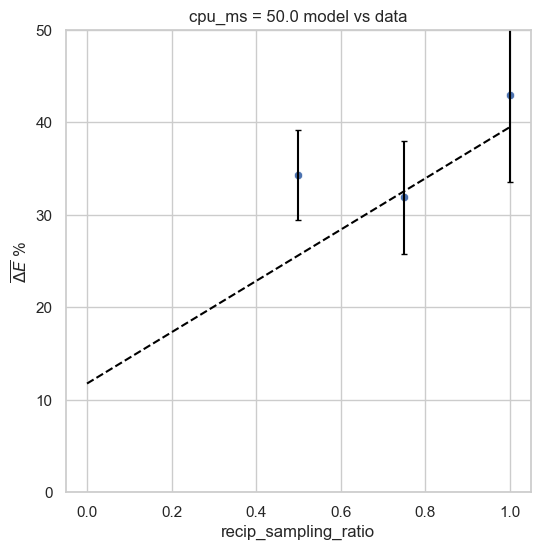

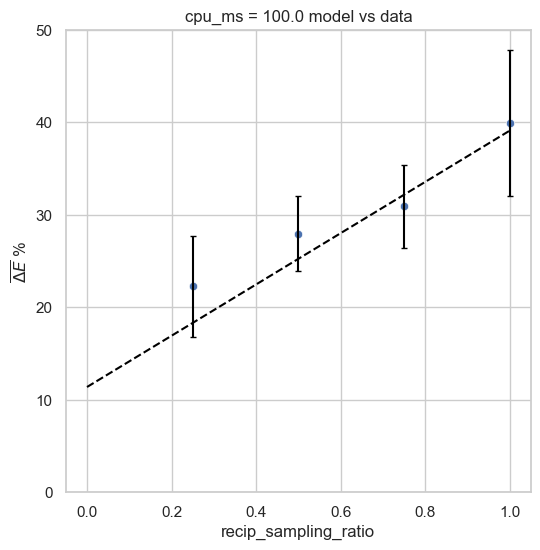

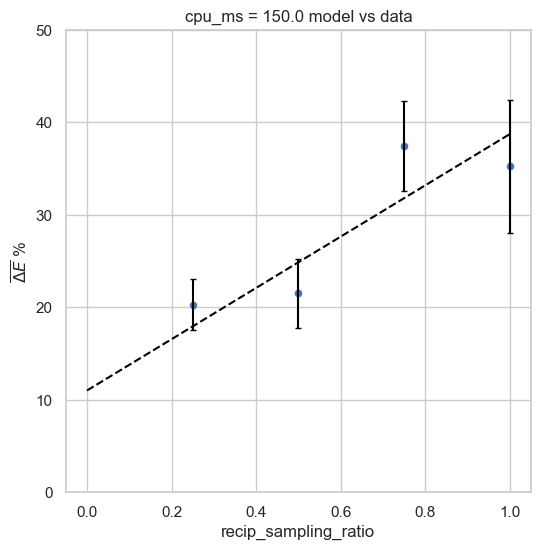

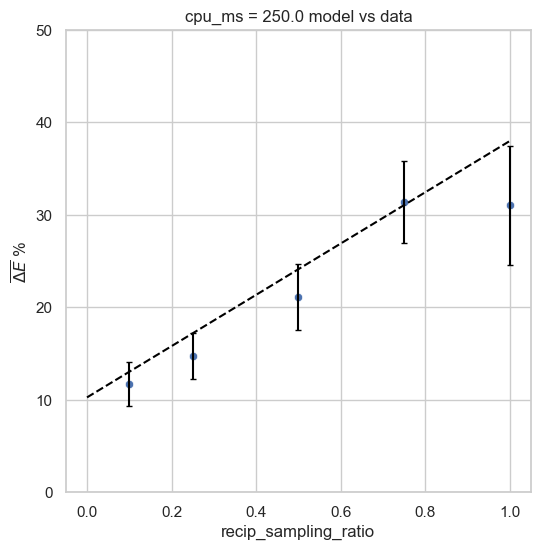

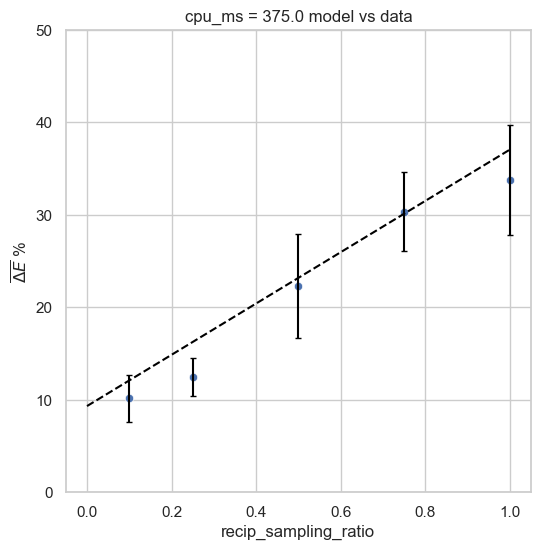

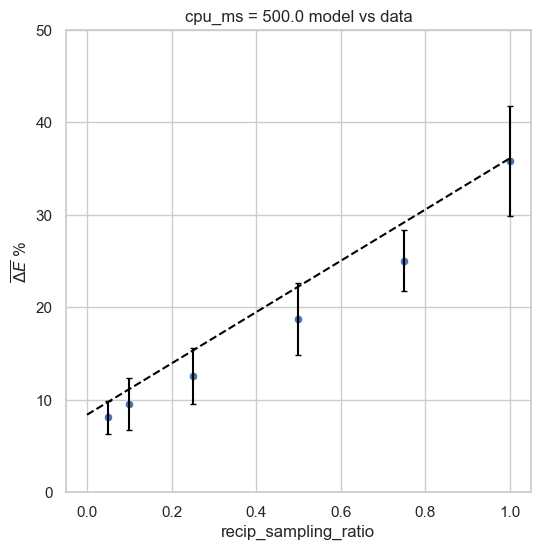

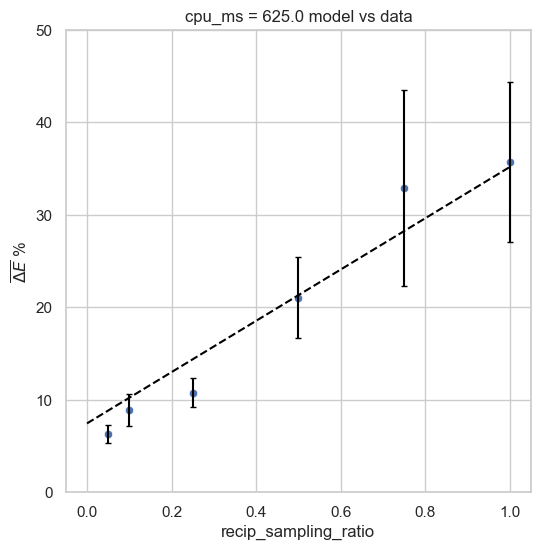

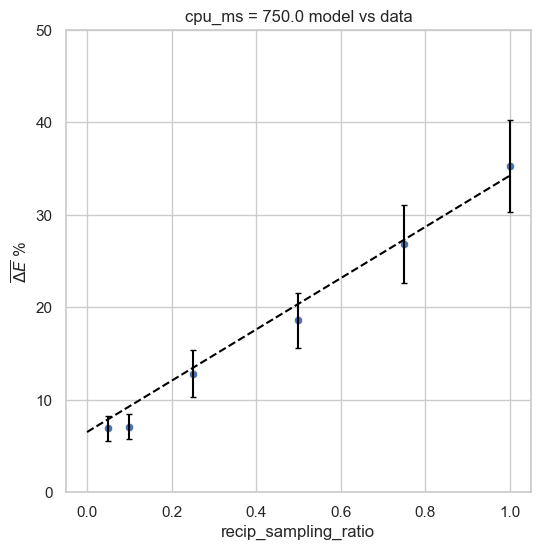

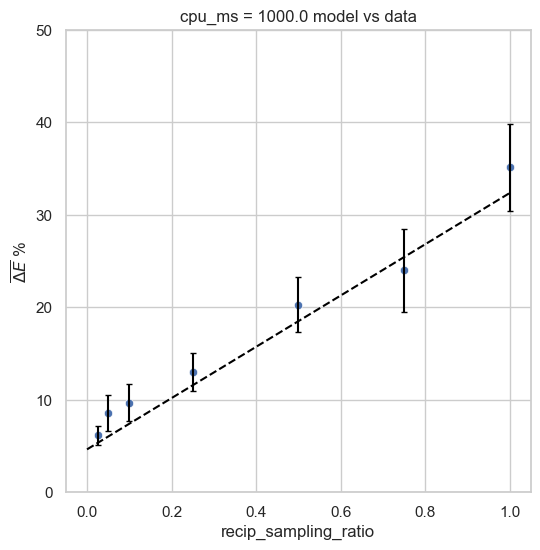

In [429]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(6,6))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, recip_model(i, x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.ylabel(r'$\overline{\Delta E}$ %')
    plt.title("cpu_ms = "+str(i)+" model vs data")
    plt.show()

In [438]:
mlr.coef_, mlr.intercept_

(array([-7.50003331e-03,  2.77470612e+01]), np.float64(12.10948180092405))

### This model: $\overline{\Delta E} (\\\%) = -0.0075*span_{ms} + 27.7470*\frac{1}{sampling\\\_ratio} + 12.1095$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

### Use CV to see if we can get a better model

In [391]:
#define cross-validation method to use
cv = KFold(n_splits=5, random_state=1, shuffle=True) 

#build multiple linear regression model
model = LinearRegression()

#use LOOCV to evaluate model
scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error',
                         cv=cv, n_jobs=-1)

#view RMSE
np.sqrt(np.mean(np.absolute(scores)))

np.float64(2.9981963026228358)

#### Not better overall!

,cpu_ms,recip_sampling_ratio
0,50.0,1.00
1,50.0,0.75
2,50.0,0.50
3,100.0,1.00
4,100.0,0.75
5,100.0,0.50
6,100.0,0.25
7,150.0,1.00
8,150.0,0.75
9,150.0,0.50


### Oversample the short spans (<200 ms)?

In [430]:
short_spans = pd.concat([X[:11]]*4, ignore_index=True)
short_means = pd.concat([y[:11]]*4, ignore_index=True)
X2 = pd.concat([X, short_spans], axis=0, ignore_index=True)
y2 = pd.concat([y, short_means], axis=0, ignore_index=True)
X2,y2


(    cpu_ms  recip_sampling_ratio
 0     50.0                  1.00
 1     50.0                  0.75
 2     50.0                  0.50
 3    100.0                  1.00
 4    100.0                  0.75
 ..     ...                   ...
 85   100.0                  0.25
 86   150.0                  1.00
 87   150.0                  0.75
 88   150.0                  0.50
 89   150.0                  0.25
 
 [90 rows x 2 columns],
 0     43.005437
 1     31.890456
 2     34.346073
 3     39.958558
 4     30.899346
         ...    
 85    22.266461
 86    35.232038
 87    37.426719
 88    21.483568
 89    20.261972
 Name: mean_energy_deviation, Length: 90, dtype: float64)

In [431]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X2, y2, test_size = 0.2, random_state = 47)

In [432]:
mlr2 = LinearRegression()  
mlr2.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(x, mlr2.coef_)), "\n Intercept: ", mlr2.intercept_)

Coefficients:  [('cpu_ms', np.float64(-0.010533372257406)), ('recip_sampling_ratio', np.float64(25.831751341611376))] 
 Intercept:  15.076276712650666


In [433]:
# make predictions based on test data
y_pred = mlr2.predict(x_test)

In [434]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  3.0348830186782534
The R^2 is:  0.9287379282370167


#### Worse RMSE, but improved $R^{2}$

#### Plot some of the fits and original data

In [435]:
mlr2.coef_, mlr2.intercept_
# make function for using regression model
def recip_model2(cpu_ms, recip_ratio):
    return (mlr2.intercept_ + mlr2.coef_[0]*cpu_ms + mlr2.coef_[1]*recip_ratio)

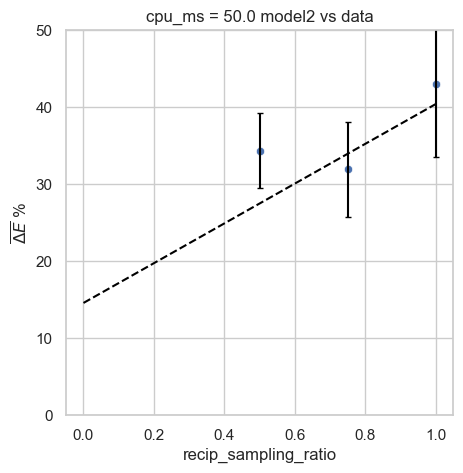

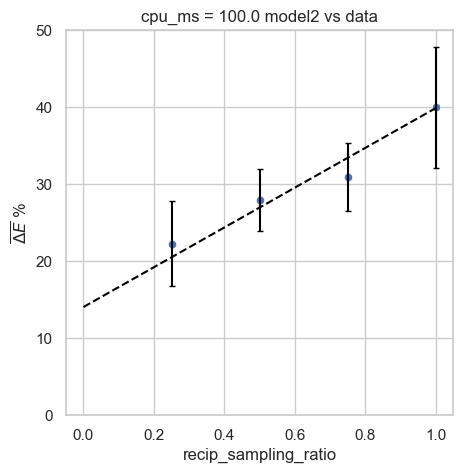

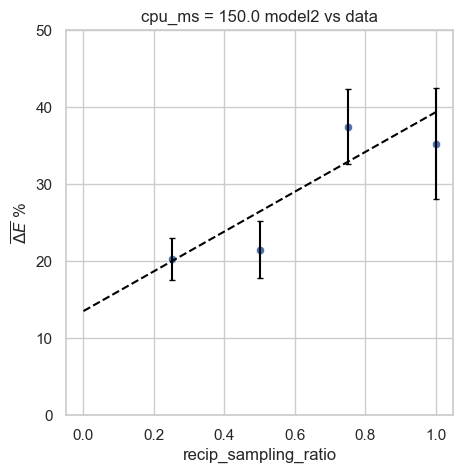

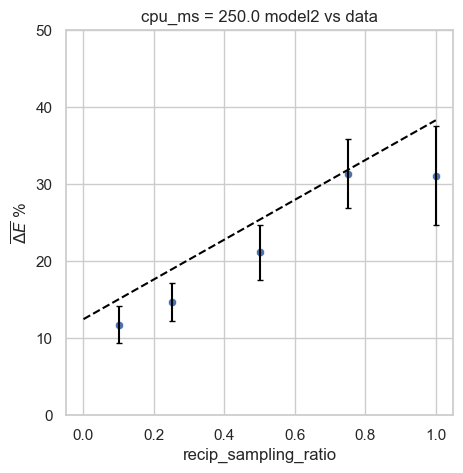

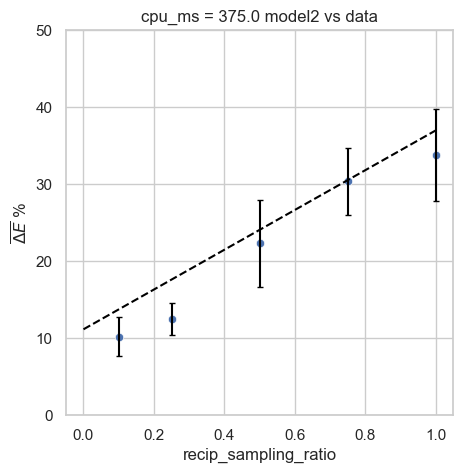

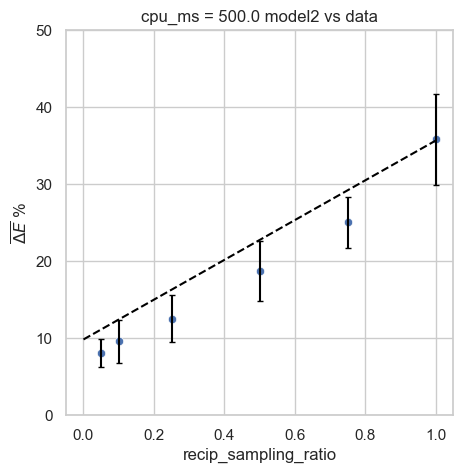

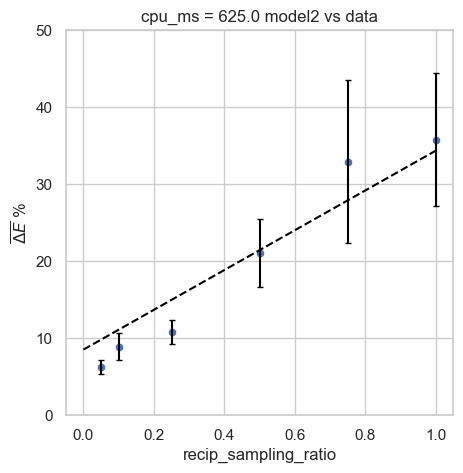

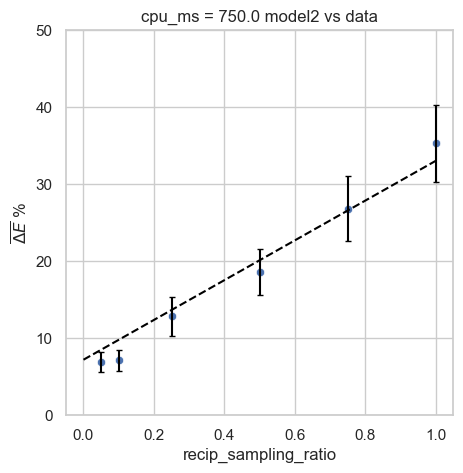

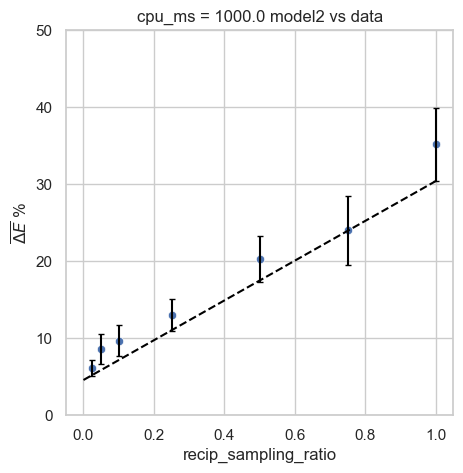

In [436]:
span_lengths = np.unique(df_mean_dev.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    temp_df = df_mean_dev.drop(['sampling_ratio','std_energy_deviation'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=temp_df, x=temp_df['recip_sampling_ratio'], y=temp_df['mean_energy_deviation'])
    plt.errorbar(temp_df['recip_sampling_ratio'], temp_df['mean_energy_deviation'], yerr=temp_df['conf_int_95'], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, recip_model2(i, x_vals), color="black", linestyle="--")
    plt.ylim(0,50)
    plt.ylabel(r'$\overline{\Delta E}$ %')
    plt.title("cpu_ms = "+str(i)+" model2 vs data")
    plt.show()

In [437]:
mlr2.coef_, mlr2.intercept_

(array([-1.05333723e-02,  2.58317513e+01]), np.float64(15.076276712650666))

### This model: $\overline{\Delta E} (\\\%) = -0.0105*span_{ms} + 25.8318*\frac{1}{sampling\\\_ratio} + 15.0763$
#### where $sampling\\\_ratio = \frac{span_{ms}}{polling\\\_interval_{ms}}$

### Random Forest Regression

In [371]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(x_train, y_train)

y_pred = rf_regressor.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

single_data = x_test.iloc[0].values.reshape(1, -1)
predicted_value = rf_regressor.predict(single_data)
print(f"Predicted Value: {predicted_value[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Predicted Value: 21.80
Actual Value: 21.48
Root Mean Squared Error: 1.19
R-squared Score: 0.99


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [372]:
single_data

array([[150. ,   0.5]])

### Quick out-of-sample text

In [377]:
test_data_point = [[300, 0.1]]
test_data_point

[[300, 0.1]]

In [380]:
predicted_value = rf_regressor.predict(test_data_point)
print(f"RF Predicted Value: {predicted_value[0]:.2f}")

RF Predicted Value: 11.89


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [381]:
# MLR2 prediction for that point
y_pred = mlr2.predict(test_data_point)
print(f"MLR Predicted Value: {y_pred[0]:.2f}")

MLR Predicted Value: 14.50


/Users/tedscott/anaconda3/envs/E2E/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
